# Exploración rápida del pipeline AUV

Ejecuta cada sección de forma independiente para verificar una etapa del modelo.
El dataset esperado es `data/lima3.nc` (Copernicus Marine / CMEMS).

**Secciones**
1. Setup
2. Datos — cargar y revisar el campo de corrientes
3. Zonas — divergencia, waypoints y centinelas
4. Grafo — construcción y estadísticos
5. Algoritmos — Bellman-Ford, matriz de costos y ATSP
6. Visualizaciones — campo, zonas, ruta 2D/3D y batería

## 1 · Setup

In [4]:
import sys, math, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.config import ParametrosModelo
from src import datos, grafo as grafo_mod, zonas, algoritmos, visualizacion, metricas

NC = pathlib.Path('..') / 'data' / 'lima3.nc'
print('Dataset:', NC.resolve())
print('Existe:', NC.exists())

Dataset: /home/axis/axis/Dev/UPC /26-1/Complejidad Algoritmica/TP-TF/TF-auv/data/lima3.nc
Existe: True


## 2 · Datos
Carga el NetCDF y muestra dimensiones, porcentaje de tierra y estadísticos de rapidez.

In [5]:
params = ParametrosModelo()
campo  = datos.cargar_corrientes(str(NC))
print(datos.resumen(campo))

Malla: 4 prof x 21 lat x 23 lon = 1932 celdas
Agua navegable: 1568  |  Tierra (NaN): 364 (18.8 %)
Latitud:  -13.08 .. -11.42
Longitud: -78.42 .. -76.58
Profundidades [m]: [0.49, 1.54, 2.65, 3.82]
Rapidez [m/s]: media 0.243  máx 0.601


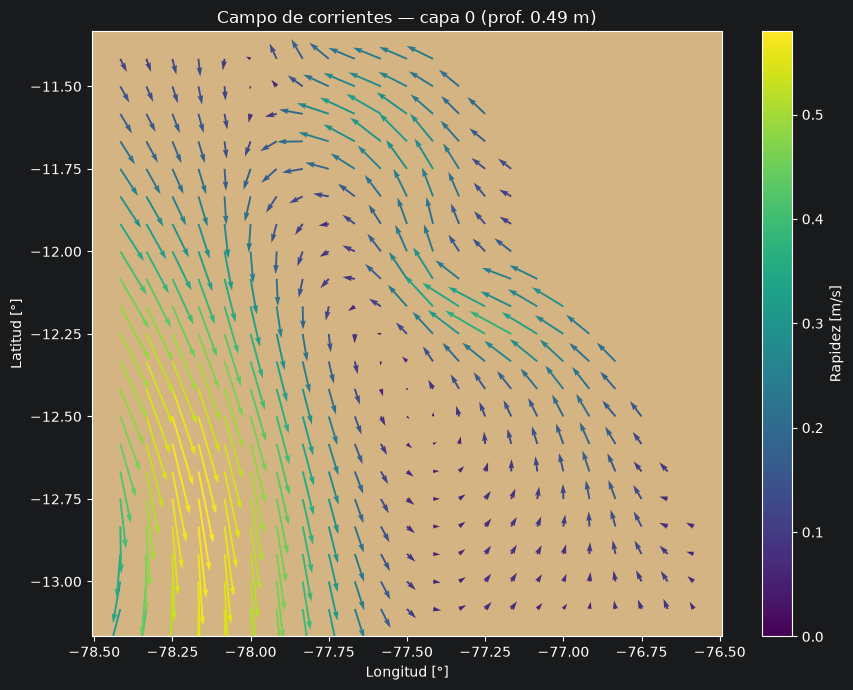

In [6]:
# Vista rápida del campo vectorial (capa 0 = superficie)
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_campo(campo, capa=0, ax=ax)
plt.tight_layout()
plt.show()

## 3 · Zonas
Calcula divergencia, selecciona waypoints de convergencia, centinelas offshore y fija la base en el Callao.

In [7]:
CAPA = 0

lat_media = math.radians(float(campo.lat.mean()))
dy = abs(float(campo.lat[1] - campo.lat[0])) * 111_320.0
dx = abs(float(campo.lon[1] - campo.lon[0])) * 111_320.0 * math.cos(lat_media)

uo  = campo.uo[CAPA]
vo  = campo.vo[CAPA]
nav = campo.navegable[CAPA]

div  = zonas.divergencia(uo, vo, dx, dy)
wps  = zonas.seleccionar_waypoints(div, nav, params.k_zonas, capa=CAPA, dist_min_celdas=3)
cent = zonas.seleccionar_centinelas(uo, vo, nav, campo.lon, n=2, capa=CAPA)
base = zonas.celda_mas_cercana(-12.05, -77.15, campo.lat, campo.lon, nav, capa=CAPA)

print(f'Waypoints de convergencia ({len(wps)}):')
for wp in wps:
    p, i, j = wp
    print(f'  {wp}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°  div={div[i,j]:.6f}')

print(f'\nCentinelas offshore ({len(cent)}):')
for c in cent:
    p, i, j = c
    print(f'  {c}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°  uo={uo[i,j]:.3f} m/s')

p, i, j = base
print(f'\nBase (Callao): {base}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°')

todos, base_nodo = zonas.agregar_puntos_fijos(wps + cent, wps[0], base)
base_idx = todos.index(base_nodo)
print(f'\nTotal waypoints misión: {len(todos)}  →  {math.factorial(len(todos)-1)} órdenes ATSP')

Waypoints de convergencia (6):
  (0, 10, 13)  lat=-12.250°  lon=-77.333°  div=-0.000006
  (0, 20, 9)  lat=-11.417°  lon=-77.667°  div=-0.000006
  (0, 17, 6)  lat=-11.667°  lon=-77.917°  div=-0.000004
  (0, 11, 16)  lat=-12.167°  lon=-77.083°  div=-0.000004
  (0, 2, 21)  lat=-12.917°  lon=-76.667°  div=-0.000003
  (0, 20, 3)  lat=-11.417°  lon=-78.167°  div=-0.000002

Centinelas offshore (2):
  (0, 11, 0)  lat=-12.167°  lon=-78.417°  uo=0.237 m/s
  (0, 6, 5)  lat=-12.583°  lon=-78.000°  uo=0.118 m/s

Base (Callao): (0, 12, 15)  lat=-12.083°  lon=-77.167°

Total waypoints misión: 9  →  40320 órdenes ATSP


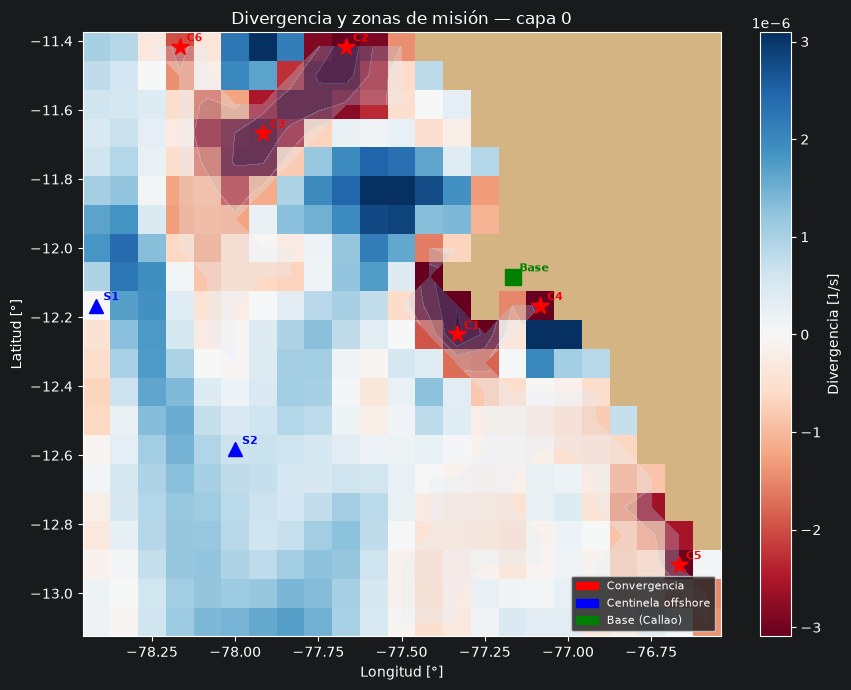

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_zonas(campo, div, wps, centinelas=cent, base=base, capa=CAPA, ax=ax)
plt.tight_layout()
plt.show()

## 4 · Grafo
Construye el grafo dirigido ponderado. Puede tardar ~1 min según tamaño del dominio.

In [9]:
g = grafo_mod.construir_grafo(campo, params)
print(f'Nodos:   {g.num_nodos:,}')
print(f'Aristas: {g.num_aristas:,}')
print(f'Factor de ramificación medio: {g.num_aristas / g.num_nodos:.1f}')

# Distribución de pesos (muestra del 1 % de las aristas)
pesos = np.array([w for _, _, w in g.aristas()])
print(f'\nPesos [J]  min={pesos.min():.2f}  media={pesos.mean():.2f}  max={pesos.max():.2f}')
print(f'Aristas negativas (regeneración): {(pesos < 0).sum():,} ({100*(pesos<0).mean():.1f} %)')

Nodos:   1,568
Aristas: 31,232
Factor de ramificación medio: 19.9

Pesos [J]  min=-248.29  media=4627.97  max=31229.92
Aristas negativas (regeneración): 427 (1.4 %)


## 5 · Algoritmos
Bellman-Ford desde cada waypoint, detección de ciclos negativos, matriz de costos y resolución ATSP.

In [10]:
# Ciclos negativos (control de sanidad del modelo)
dist0, _ = algoritmos.bellman_ford(g, todos[0])
if algoritmos.hay_ciclo_negativo(g, dist0):
    print('⚠  Ciclo negativo detectado — revisar parámetros del modelo')
else:
    print('✓  Sin ciclos negativos')

✓  Sin ciclos negativos


In [11]:
# Matriz de costos entre zonas (un Bellman-Ford por waypoint)
M, caminos = algoritmos.matriz_costos(g, todos)

print('Matriz de costos [J]  (filas=origen, cols=destino):')
print(np.array2string(M, precision=1, suppress_small=True))

Matriz de costos [J]  (filas=origen, cols=destino):
[[    0.   4245.3  4113.3 21285.7 27777.  10796.3 17643.1  7144.4 13088. ]
 [22360.8     0.   6704.2 27414.2 31354.5  8726.1 18007.9  9872.  27819. ]
 [15658.1 17886.7     0.  20711.6 24651.8 12042.5 13529.8  3169.4 21116.3]
 [ 3576.4  4461.3  4828.6     0.  29244.9 11511.6 18358.4  7859.7   404.8]
 [ 7820.4 10938.8 11268.5  8231.8     0.  17951.5 24798.3 14299.5  8636.5]
 [17195.  17428.7  5283.5 22072.7 26010.4     0.   9768.1  4482.3 22477.5]
 [18339.9 21655.5 21810.  19483.1 21852.5 28493.      0.    233.6 19887.8]
 [18107.  21422.6 21577.1 19250.2 21619.7 28260.1 35106.9     0.  19655. ]
 [ 5465.8  4713.1  5684.7  8658.5 30336.2 11905.6 19214.5  8853.8     0. ]]


In [ ]:
# ATSP por fuerza bruta
orden, costo_total = algoritmos.atsp_fuerza_bruta(M, base=base_idx)
ruta = algoritmos.ensamblar_ruta(orden, caminos)

print(f'Orden óptimo de visita: {orden}')
print(f'Costo total:            {costo_total:.2f} J')
print(f'Nodos en la ruta:       {len(ruta)}')
print()
print(metricas.resumen_mision(orden, todos, M, campo))

## 6 · Visualizaciones

In [ ]:
# Ruta óptima 2D
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_ruta(campo, ruta, waypoints=wps, centinelas=cent, base=base, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Ruta 3D por capas de profundidad
fig3d = visualizacion.plot_3d(campo, ruta, waypoints=wps, centinelas=cent, base=base)
plt.tight_layout()
plt.show()

In [ ]:
# Estado de batería a lo largo de la misión
bat = metricas.estado_bateria(ruta, g, params.e_max)
print(f"Viable: {bat['viable']}  |  Mínimo: {bat['minimo']:.1f} J  |  "
      f"Consumido: {bat['consumido']:.1f} J  |  Regenerado: {bat['regenerado']:.1f} J")

fig, ax = plt.subplots(figsize=(12, 4))
visualizacion.plot_bateria(campo, ruta, bat['niveles'], params.e_max,
                           waypoints=todos, orden=orden, ax=ax)
plt.tight_layout()
plt.show()

## Extras — pruebas puntuales
Zona de scratch para probar cosas sueltas sin tocar las secciones de arriba.

In [ ]:
# Ejemplo: cambiar parámetros y ver cómo cambia la energía total
params_prueba = ParametrosModelo(s=1.0, eta=0.5, k_zonas=4)
print(params_prueba)